In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pathlib
import cv2
from google.colab.patches import cv2_imshow
from sklearn.model_selection import train_test_split
import numpy as np
import os

from tensorflow.keras.preprocessing.image import ImageDataGenerator

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout, Conv2D, MaxPooling2D
from tensorflow.keras.optimizers import Adam
from keras import models, layers

from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.applications import MobileNetV2

from tensorflow.keras import optimizers
from sklearn.utils.class_weight import compute_class_weight

from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report

import random

np.random.seed(42)
tf.random.set_seed(42)
random.seed(42)

In [ ]:
data_dir = "/content/drive/MyDrive/Colab Notebooks/gender_dataset_face"
type(data_dir)

str

In [ ]:
data_dir = pathlib.Path(data_dir)
type(data_dir)

pathlib.PosixPath

In [ ]:
data_dir.glob("*")

<generator object Path.glob at 0x7cdd038b5be0>

In [ ]:
list(data_dir.glob("*"))

[PosixPath('/content/drive/MyDrive/Colab Notebooks/gender_dataset_face/woman'),
 PosixPath('/content/drive/MyDrive/Colab Notebooks/gender_dataset_face/man')]

In [ ]:
list(data_dir.glob("woman/*"))

[PosixPath('/content/drive/MyDrive/Colab Notebooks/gender_dataset_face/woman/face_898.jpg'),
 PosixPath('/content/drive/MyDrive/Colab Notebooks/gender_dataset_face/woman/face_1339.jpg'),
 PosixPath('/content/drive/MyDrive/Colab Notebooks/gender_dataset_face/woman/face_1168.jpg'),
 PosixPath('/content/drive/MyDrive/Colab Notebooks/gender_dataset_face/woman/face_1207.jpg'),
 PosixPath('/content/drive/MyDrive/Colab Notebooks/gender_dataset_face/woman/face_1256.jpg'),
 PosixPath('/content/drive/MyDrive/Colab Notebooks/gender_dataset_face/woman/face_1081.jpg'),
 PosixPath('/content/drive/MyDrive/Colab Notebooks/gender_dataset_face/woman/face_913.jpg'),
 PosixPath('/content/drive/MyDrive/Colab Notebooks/gender_dataset_face/woman/face_1046.jpg'),
 PosixPath('/content/drive/MyDrive/Colab Notebooks/gender_dataset_face/woman/face_1170.jpg'),
 PosixPath('/content/drive/MyDrive/Colab Notebooks/gender_dataset_face/woman/face_1187.jpg'),
 PosixPath('/content/drive/MyDrive/Colab Notebooks/gender_data

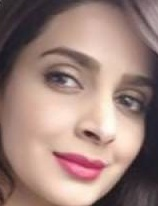

In [ ]:
myimg = cv2_imshow(cv2.imread(list(data_dir.glob("woman/*"))[17]))

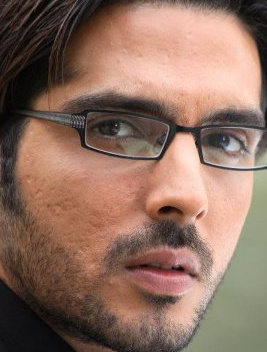

In [ ]:
myimg = cv2_imshow(cv2.imread(list(data_dir.glob("man/*"))[30]))

In [ ]:
print(len(list(data_dir.glob("woman/*"))))
print(len(list(data_dir.glob("man/*"))))

1134
1173


In [ ]:
1134 + 1173

2307

In [ ]:
gender_images_dict = {
    'Woman': list(data_dir.glob('woman/*')),
    'Man': list(data_dir.glob('man/*')),
}
gender_labels_dict = {
    'Woman': 0,
    'Man': 1,
}

In [ ]:
# X, y = [], []

# for gender, images in gender_images_dict.items():
#     for image in images:
#         img = cv2.imread(image)
#         img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

#         resized_img = cv2.resize(img,(224,224))
#         resized_img = preprocess_input(resized_img)   # scales to [-1,1]

#         X.append(resized_img)
#         y.append(gender_labels_dict[gender])

In [ ]:
# X = np.array(X)
# y = np.array(y)

In [ ]:
# np.savez_compressed("/content/drive/MyDrive/Colab Notebooks/gender_dataset_mobileNet.npz", X=X, y=y)

In [ ]:
data = np.load("/content/drive/MyDrive/Colab Notebooks/gender_dataset_mobileNet.npz")

X = data["X"]
y = data["y"]

In [ ]:
X.shape

(2307, 224, 224, 3)

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.15,
    stratify=y,
    random_state=42
)

x_train_final, x_val, y_train_final, y_val = train_test_split(
    x_train,
    y_train,
    test_size=0.1765,
    stratify=y_train,
    random_state=42
)

In [ ]:
print("Train:", np.bincount(y_train_final))
print("Validation:", np.bincount(y_val))
print("Test:", np.bincount(y_test))

Train: [793 821]
Validation: [170 176]
Test: [171 176]


class distribution remains consistent across splits

In [ ]:
train_datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.08,
    height_shift_range=0.08,
    zoom_range=0.15,
    horizontal_flip=True,
    brightness_range=[0.8,1.2],
    fill_mode="nearest"
)

train_generator = train_datagen.flow(
    x_train_final,
    y_train_final,
    batch_size=32,
    shuffle=True
)

In [ ]:
val_datagen = ImageDataGenerator()

val_generator = val_datagen.flow(
    x_val,
    y_val,
    batch_size=32,
    shuffle=False
)

**Insights:**

Data augmentation was applied to the training data to simulate real-world variations such as slight rotations, shifts, zoom, and lighting changes. This helps the model generalize better and reduces overfitting by exposing it to more diverse facial patterns during training, while validation data remained unchanged to ensure unbiased evaluation.

# A. MobileNetV2 :-

In [ ]:
checkpointer = ModelCheckpoint(
    filepath='/content/drive/MyDrive/Colab Notebooks/gender_detection_best_mobileNet_model.keras',
    monitor='val_loss',
    save_best_only=True,
    mode='min',
    verbose=1
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

lr_reduce = ReduceLROnPlateau(
    monitor='val_loss',
    patience=3,
    factor=0.3,
    min_lr=1e-6,
    verbose=1
)

In [ ]:
base_model = MobileNetV2(
    input_shape=(224,224,3),
    include_top=False,
    weights='imagenet'
)

base_model.trainable = False

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
mobilenet_model = models.Sequential()

mobilenet_model.add(base_model)

mobilenet_model.add(layers.GlobalAveragePooling2D())

mobilenet_model.add(layers.Dense(128, activation='relu'))
mobilenet_model.add(layers.Dropout(0.4))

mobilenet_model.add(layers.Dense(1, activation='sigmoid'))

In [ ]:
mobilenet_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,081 (9.24 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
mobilenet_model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history_mobilenet = mobilenet_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=40,
    callbacks=[checkpointer, early_stop, lr_reduce],
    verbose=2
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/40

Epoch 1: val_loss improved from inf to 0.36710, saving model to /content/drive/MyDrive/Colab Notebooks/gender_detection_best_mobileNet_model.keras
51/51 - 73s - 1s/step - accuracy: 0.7082 - loss: 0.5577 - val_accuracy: 0.8555 - val_loss: 0.3671 - learning_rate: 1.0000e-04
Epoch 2/40

Epoch 2: val_loss improved from 0.36710 to 0.27151, saving model to /content/drive/MyDrive/Colab Notebooks/gender_detection_best_mobileNet_model.keras
51/51 - 22s - 434ms/step - accuracy: 0.8575 - loss: 0.3473 - val_accuracy: 0.8988 - val_loss: 0.2715 - learning_rate: 1.0000e-04
Epoch 3/40

Epoch 3: val_loss improved from 0.27151 to 0.25546, saving model to /content/drive/MyDrive/Colab Notebooks/gender_detection_best_mobileNet_model.keras
51/51 - 24s - 471ms/step - accuracy: 0.8773 - loss: 0.2821 - val_accuracy: 0.8873 - val_loss: 0.2555 - learning_rate: 1.0000e-04
Epoch 4/40

Epoch 4: val_loss improved from 0.25546 to 0.24155, saving model to /content/drive/MyDrive/Colab Notebooks/gender_detec

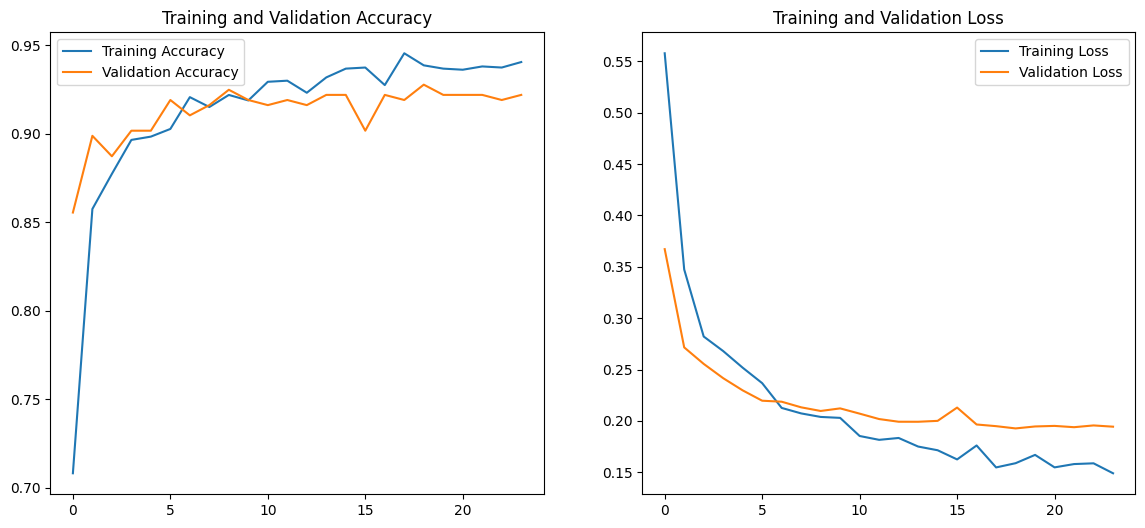

In [ ]:
# Plot training metrics
acc = history_mobilenet.history['accuracy']
val_acc = history_mobilenet.history['val_accuracy']
loss = history_mobilenet.history['loss']
val_loss = history_mobilenet.history['val_loss']
epochs_range = range(len(acc))

plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend()
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend()
plt.title('Training and Validation Loss')
plt.show()

In [ ]:
mobilenet_model.evaluate(x_test, y_test)

11/11 ━━━━━━━━━━━━━━━━━━━━ 13s 1s/step - accuracy: 0.9372 - loss: 0.1318


[0.16129346191883087, 0.9279538989067078]

In [ ]:
y_pred_prob = mobilenet_model.predict(x_test)

y_pred = (y_pred_prob > 0.5).astype("int32").flatten()

print(classification_report(
    y_test,
    y_pred,
    zero_division=0
))

11/11 ━━━━━━━━━━━━━━━━━━━━ 13s 483ms/step
              precision    recall  f1-score   support

           0       0.93      0.92      0.93       171
           1       0.93      0.93      0.93       176

    accuracy                           0.93       347
   macro avg       0.93      0.93      0.93       347
weighted avg       0.93      0.93      0.93       347



> In this experiment, transfer learning using MobileNetV2 was applied for gender classification from facial images. The pretrained MobileNetV2 model was used as a feature extractor while a custom classification head was trained on the dataset. Compared to the custom CNN trained from scratch, MobileNetV2 achieved significantly higher accuracy (~93%). The balanced precision, recall, and F1-scores indicate that the model generalizes well across both classes without bias. This demonstrates the effectiveness of transfer learning in improving performance when working with relatively small image datasets.

## Model Comparison

Two different models were implemented for the gender detection task: a **Custom CNN trained from scratch** and a **MobileNetV2 transfer learning model**. Both models were trained and evaluated using the same dataset and preprocessing pipeline.

| Metric | Custom CNN | MobileNetV2 |
|------|------|------|
| Approach | CNN trained from scratch | Transfer learning using pretrained MobileNetV2 |
| Test Accuracy | ~67% | ~93% |
| Precision | ~0.67 | ~0.93 |
| Recall | ~0.67 | ~0.93 |
| F1-score | ~0.67 | ~0.93 |
| Generalization | Moderate | Very good |
| Training Efficiency | Slower convergence | Faster convergence |

### Observations

- The **Custom CNN** learned basic facial features but achieved limited performance due to the relatively small dataset.
- The **MobileNetV2 model** leveraged pretrained ImageNet features, enabling it to capture richer facial representations.
- The MobileNetV2 model produced **balanced precision and recall for both classes**, indicating stable and unbiased predictions.
- This experiment highlights the advantage of **transfer learning for image classification tasks with limited data**.

### Conclusion

The MobileNetV2 model significantly outperformed the Custom CNN, achieving higher accuracy and better generalization. This demonstrates that transfer learning is highly effective for facial image classification problems when training data is limited.